In [1]:
!pip install -q kagglehub nibabel scikit-image torchsummary tqdm monai
import os, gc, math, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import nibabel as nib
import scipy.ndimage as ndimage
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

# Seeds
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 43.4 MB/s eta 0:00:00
Device: cuda
GPU: Tesla T4


In [2]:
import kagglehub

path = kagglehub.dataset_download("awsaf49/brats20-dataset-training-validation")
print("Path to dataset files:", path)

# Explore structure
DATA_ROOT = Path(path)
all_files = list(DATA_ROOT.rglob('*'))
dirs = [f for f in all_files if f.is_dir()]
files = [f for f in all_files if f.is_file()]

print(f"\nTotal directories: {len(dirs)}")
print(f"Total files: {len(files)}")
print("\nTop-level contents:")
for d in sorted(DATA_ROOT.iterdir()):
    print(f"  {d.name}/")

print("\nFirst 5 dirs:")
for d in sorted(dirs)[:5]:
    print(f"  {d}")

print("\nSample files (first 10):")
for f in sorted(files)[:10]:
    print(f"  {f.name}")

Using Colab cache for faster access to the 'brats20-dataset-training-validation' dataset.
Path to dataset files: /kaggle/input/brats20-dataset-training-validation

Total directories: 498
Total files: 2349

Top-level contents:
  BraTS2020_TrainingData/
  BraTS2020_ValidationData/

First 5 dirs:
  /kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData
  /kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
  /kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001
  /kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_002
  /kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_003

Sample files (first 10):
  BraTS20_Training_001_flair.nii
  BraTS20_Training_001_seg.nii
  BraTS20_Training_001_t1.nii
  BraTS20_Training_001_t1ce

In [3]:
# Define paths
TRAIN_DIR = DATA_ROOT / 'BraTS2020_TrainingData' / 'MICCAI_BraTS2020_TrainingData'

# Get all patient folders, limit to first 50 for Colab memory
patient_dirs = sorted([d for d in TRAIN_DIR.iterdir() if d.is_dir()])[:50]
print(f"Total patients available: {len(sorted([d for d in TRAIN_DIR.iterdir() if d.is_dir()]))}")
print(f"Using first {len(patient_dirs)} patients")

# Verify each patient has t2 and seg
valid_patients = []
for p in patient_dirs:
    t2  = list(p.glob('*_t2.nii'))
    seg = list(p.glob('*_seg.nii'))
    if t2 and seg:
        valid_patients.append({'t2': t2[0], 'seg': seg[0], 'id': p.name})
    else:
        print(f"  WARNING: missing files in {p.name}")

print(f"\nValid patients with t2 + seg: {len(valid_patients)}")
print("\nSample pair:")
print(f"  T2 : {valid_patients[0]['t2'].name}")
print(f"  Seg: {valid_patients[0]['seg'].name}")

Total patients available: 369
Using first 50 patients

Valid patients with t2 + seg: 50

Sample pair:
  T2 : BraTS20_Training_001_t2.nii
  Seg: BraTS20_Training_001_seg.nii


T2  shape : (240, 240, 155)
Seg shape : (240, 240, 155)
T2  dtype : float64
Seg dtype : float64
T2  min/max: 0.00 / 376.00
Seg unique values: [0. 1. 2. 4.]
Seg value meanings: 0=background, 1=necrotic core, 2=edema, 4=enhancing tumor

Total axial slices: 155
Slices with tumor: 83
Tumor slice range: 30 → 112


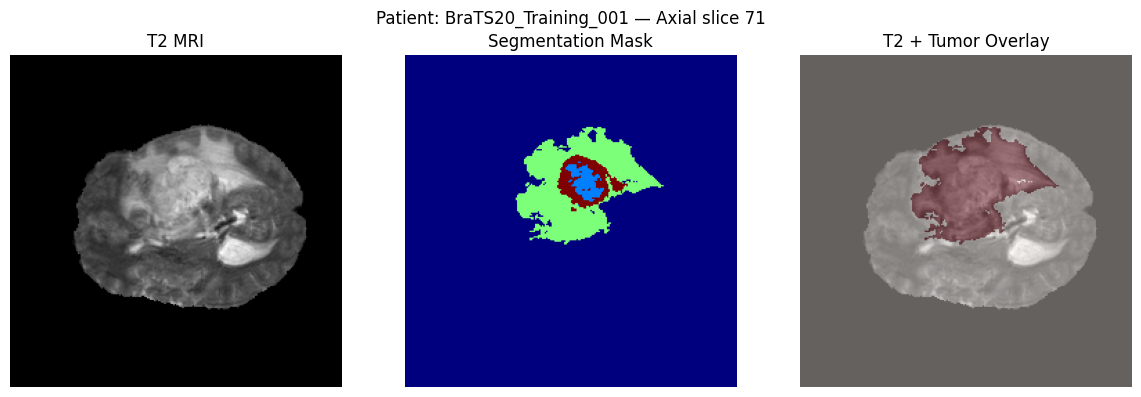

In [4]:
# Load one patient to understand data structure
sample = valid_patients[0]

t2_vol  = nib.load(str(sample['t2'])).get_fdata()
seg_vol = nib.load(str(sample['seg'])).get_fdata()

print(f"T2  shape : {t2_vol.shape}")
print(f"Seg shape : {seg_vol.shape}")
print(f"T2  dtype : {t2_vol.dtype}")
print(f"Seg dtype : {seg_vol.dtype}")
print(f"T2  min/max: {t2_vol.min():.2f} / {t2_vol.max():.2f}")
print(f"Seg unique values: {np.unique(seg_vol)}")
print(f"Seg value meanings: 0=background, 1=necrotic core, 2=edema, 4=enhancing tumor")

# Count slices with tumor per volume
tumor_slices = []
for z in range(seg_vol.shape[2]):
    if seg_vol[:, :, z].sum() > 0:
        tumor_slices.append(z)
print(f"\nTotal axial slices: {seg_vol.shape[2]}")
print(f"Slices with tumor: {len(tumor_slices)}")
print(f"Tumor slice range: {min(tumor_slices)} → {max(tumor_slices)}")

# Visualize middle tumor slice
mid = tumor_slices[len(tumor_slices)//2]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle(f"Patient: {sample['id']} — Axial slice {mid}", fontsize=12)
axes[0].imshow(t2_vol[:, :, mid], cmap='gray')
axes[0].set_title('T2 MRI'); axes[0].axis('off')
axes[1].imshow(seg_vol[:, :, mid], cmap='jet')
axes[1].set_title('Segmentation Mask'); axes[1].axis('off')
axes[2].imshow(t2_vol[:, :, mid], cmap='gray')
axes[2].imshow(seg_vol[:, :, mid] > 0, cmap='Reds', alpha=0.4)
axes[2].set_title('T2 + Tumor Overlay'); axes[2].axis('off')
plt.tight_layout(); plt.show()

In [5]:
from skimage.transform import resize

def extract_slices(patient_list, img_size=256):
    slices = []
    for p in tqdm(patient_list, desc='Loading patients'):
        try:
            t2  = nib.load(str(p['t2'])).get_fdata()
            seg = nib.load(str(p['seg'])).get_fdata()
        except Exception as e:
            print(f"WARNING: skipping {p['id']} — {e}")
            continue

        # normalize t2 to [0,1] first using 99th percentile to avoid outliers
        p99 = np.percentile(t2, 99)
        if p99 > 0:
            t2 = np.clip(t2, 0, p99) / p99

        # binarize seg: any tumor class → 1
        seg_bin = (seg > 0).astype(np.float32)

        for z in range(t2.shape[2]):
            mask_slice = seg_bin[:, :, z]
            # only keep slices with meaningful tumor (>50 pixels)
            if mask_slice.sum() < 50:
                continue

            t2_slice  = t2[:, :, z].astype(np.float32)

            # resize to 256x256
            t2_resized  = resize(t2_slice,  (img_size, img_size),
                                  anti_aliasing=True).astype(np.float32)
            seg_resized = resize(mask_slice, (img_size, img_size),
                                  anti_aliasing=False, order=0).astype(np.float32)
            seg_resized = (seg_resized > 0.5).astype(np.float32)

            slices.append({
                'mri':    t2_resized,
                'mask':   seg_resized,
                'patient': p['id'],
                'slice':   z
            })

    return slices

all_slices = extract_slices(valid_patients)
print(f"\nTotal slices extracted: {len(all_slices)}")
print(f"MRI  shape: {all_slices[0]['mri'].shape}")
print(f"Mask shape: {all_slices[0]['mask'].shape}")
print(f"MRI  min/max: {all_slices[0]['mri'].min():.3f} / {all_slices[0]['mri'].max():.3f}")
print(f"Mask unique: {np.unique(all_slices[0]['mask'])}")

# Tumor size distribution
tumor_sizes = [s['mask'].sum() for s in all_slices]
print(f"\nTumor size stats (pixels):")
print(f"  Min:  {min(tumor_sizes):.0f}")
print(f"  Max:  {max(tumor_sizes):.0f}")
print(f"  Mean: {np.mean(tumor_sizes):.0f}")
print(f"  Std:  {np.std(tumor_sizes):.0f}")

Loading patients: 100%|██████████| 50/50 [00:37<00:00,  1.34it/s]


Total slices extracted: 3078
MRI  shape: (256, 256)
Mask shape: (256, 256)
MRI  min/max: 0.000 / 1.000
Mask unique: [0. 1.]

Tumor size stats (pixels):
  Min:  54
  Max:  5762
  Mean: 1507
  Std:  1154


Train patients: 35 → 2185 slices
Val   patients: 7   → 436 slices
Test  patients: 8  → 457 slices


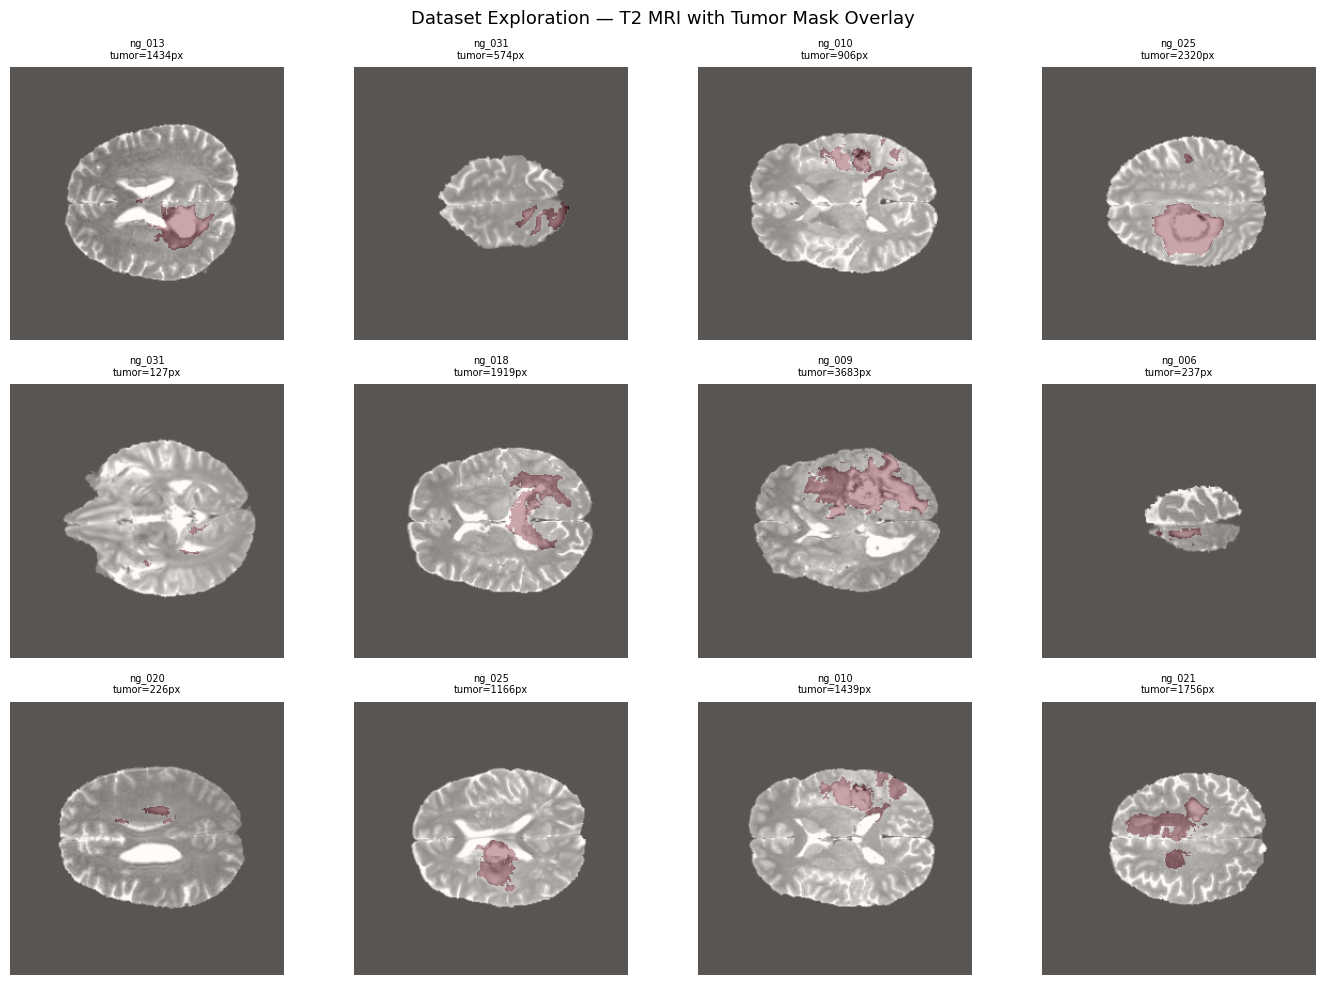

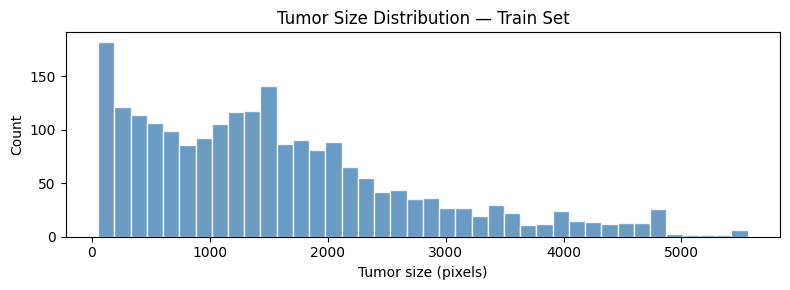

In [6]:
from sklearn.model_selection import train_test_split

# Split by patient to avoid data leakage
patient_ids = list(set([s['patient'] for s in all_slices]))
random.shuffle(patient_ids)

train_ids, temp_ids = train_test_split(patient_ids, test_size=0.30, random_state=42)
val_ids,   test_ids = train_test_split(temp_ids,    test_size=0.50, random_state=42)

train_slices = [s for s in all_slices if s['patient'] in train_ids]
val_slices   = [s for s in all_slices if s['patient'] in val_ids]
test_slices  = [s for s in all_slices if s['patient'] in test_ids]

print(f"Train patients: {len(train_ids)} → {len(train_slices)} slices")
print(f"Val   patients: {len(val_ids)}   → {len(val_slices)} slices")
print(f"Test  patients: {len(test_ids)}  → {len(test_slices)} slices")

# Visualize 12 random samples
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Dataset Exploration — T2 MRI with Tumor Mask Overlay', fontsize=13)
indices = random.sample(range(len(train_slices)), 12)
for ax, idx in zip(axes.ravel(), indices):
    s = train_slices[idx]
    ax.imshow(s['mri'], cmap='gray')
    ax.imshow(s['mask'], cmap='Reds', alpha=0.35)
    ax.set_title(f"{s['patient'][-6:]}\ntumor={s['mask'].sum():.0f}px", fontsize=7)
    ax.axis('off')
plt.tight_layout(); plt.show()

# Tumor size distribution
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist([s['mask'].sum() for s in train_slices], bins=40,
        color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('Tumor size (pixels)'); ax.set_ylabel('Count')
ax.set_title('Tumor Size Distribution — Train Set')
plt.tight_layout(); plt.show()

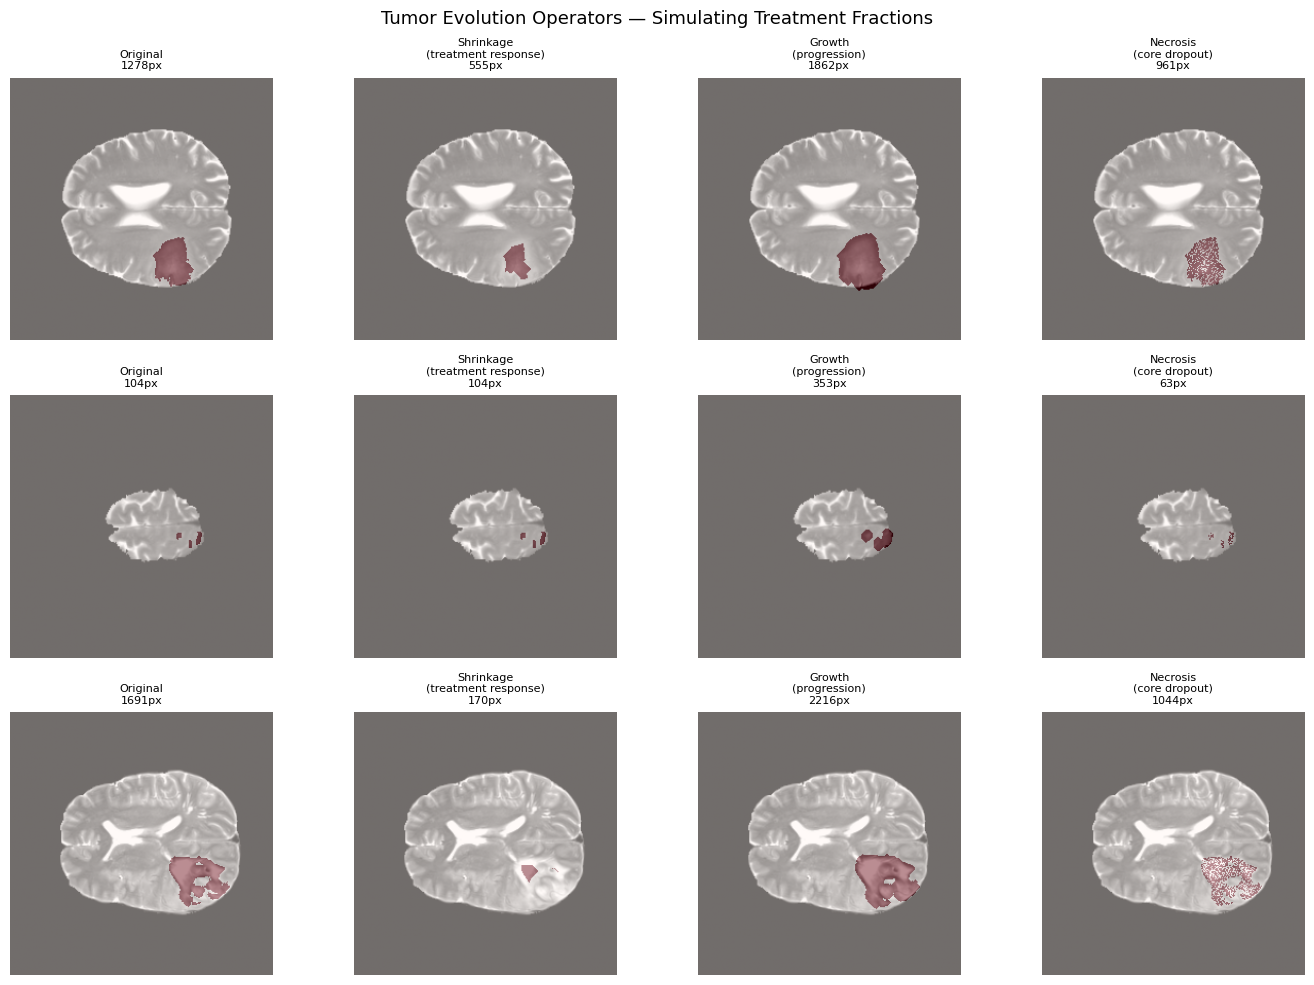

Evolution operator test:
  Original  : 99 px
  Shrinkage : 99 px  (0.0%)
  Growth    : 431 px  (335.4%)
  Necrosis  : 58 px  (-41.4%)


In [7]:
def apply_shrinkage(mask, iterations=None):
    """Simulate treatment response — tumor shrinks"""
    if iterations is None:
        iterations = random.randint(3, 8)
    eroded = ndimage.binary_erosion(mask, iterations=iterations).astype(np.float32)
    return eroded if eroded.sum() > 20 else mask  # fallback if too small

def apply_growth(mask, iterations=None):
    """Simulate tumor progression — tumor grows"""
    if iterations is None:
        iterations = random.randint(2, 6)
    return ndimage.binary_dilation(mask, iterations=iterations).astype(np.float32)

def apply_necrosis(mask, dropout_ratio=None):
    """Simulate necrotic core — random dropout inside tumor"""
    if dropout_ratio is None:
        dropout_ratio = random.uniform(0.2, 0.5)
    result = mask.copy()
    tumor_pixels = np.argwhere(mask > 0)
    if len(tumor_pixels) == 0:
        return mask
    n_drop = int(len(tumor_pixels) * dropout_ratio)
    drop_idx = np.random.choice(len(tumor_pixels), n_drop, replace=False)
    for idx in drop_idx:
        result[tumor_pixels[idx][0], tumor_pixels[idx][1]] = 0
    return result.astype(np.float32)

def apply_evolution(mask, mode=None):
    """Apply random evolution operator"""
    if mode is None:
        r = random.random()
        if r < 0.5:   mode = 'shrinkage'
        elif r < 0.8: mode = 'growth'
        else:          mode = 'necrosis'
    if mode == 'shrinkage': return apply_shrinkage(mask), mode
    elif mode == 'growth':  return apply_growth(mask),    mode
    else:                   return apply_necrosis(mask),  mode

# Visualize tumor evolution operators on 3 samples
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Tumor Evolution Operators — Simulating Treatment Fractions', fontsize=13)
sample_indices = random.sample(range(len(train_slices)), 3)

for row, idx in enumerate(sample_indices):
    s = train_slices[idx]
    mask = s['mask']
    shrunk,  _ = apply_evolution(mask, 'shrinkage')
    grown,   _ = apply_evolution(mask, 'growth')
    necrotic,_ = apply_evolution(mask, 'necrosis')

    ops   = [mask, shrunk, grown, necrotic]
    titles = ['Original', 'Shrinkage\n(treatment response)',
              'Growth\n(progression)', 'Necrosis\n(core dropout)']
    for col, (op, title) in enumerate(zip(ops, titles)):
        axes[row, col].imshow(s['mri'], cmap='gray')
        axes[row, col].imshow(op, cmap='Reds', alpha=0.45)
        px = op.sum()
        axes[row, col].set_title(f"{title}\n{px:.0f}px", fontsize=8)
        axes[row, col].axis('off')

plt.tight_layout(); plt.show()

# Stats
print("Evolution operator test:")
m = train_slices[0]['mask']
s, _ = apply_evolution(m, 'shrinkage')
g, _ = apply_evolution(m, 'growth')
n, _ = apply_evolution(m, 'necrosis')
print(f"  Original  : {m.sum():.0f} px")
print(f"  Shrinkage : {s.sum():.0f} px  ({(s.sum()-m.sum())/m.sum()*100:.1f}%)")
print(f"  Growth    : {g.sum():.0f} px  ({(g.sum()-m.sum())/m.sum()*100:.1f}%)")
print(f"  Necrosis  : {n.sum():.0f} px  ({(n.sum()-m.sum())/m.sum()*100:.1f}%)")

In [8]:
import torchvision.transforms.functional as TF

class TumorEvolutionDataset(Dataset):
    def __init__(self, slices, augment=False):
        self.slices  = slices
        self.augment = augment

    def __len__(self):
        return len(self.slices)

    def __getitem__(self, idx):
        s    = self.slices[idx]
        mri  = s['mri'].copy()   # [0, 1]
        mask = s['mask'].copy()  # binary {0, 1}

        # Apply tumor evolution to get modified mask (condition)
        evolved_mask, mode = apply_evolution(mask)

        # Augmentation on training set
        if self.augment:
            if random.random() > 0.5:
                mri          = np.fliplr(mri).copy()
                mask         = np.fliplr(mask).copy()
                evolved_mask = np.fliplr(evolved_mask).copy()
            if random.random() > 0.5:
                mri          = np.flipud(mri).copy()
                mask         = np.flipud(mask).copy()
                evolved_mask = np.flipud(evolved_mask).copy()

        # Normalize MRI to [-1, 1] for Tanh generator output
        mri_tanh = (mri * 2.0) - 1.0

        # Convert to tensors [C, H, W]
        mri_tensor     = torch.tensor(mri_tanh,     dtype=torch.float32).unsqueeze(0)
        mask_tensor    = torch.tensor(mask,          dtype=torch.float32).unsqueeze(0)
        evolved_tensor = torch.tensor(evolved_mask,  dtype=torch.float32).unsqueeze(0)

        # Generator input: concat(evolved_mask, mri) — condition + input
        # Generator target: real mri (in [-1,1])
        return mri_tensor, mask_tensor, evolved_tensor, mode

train_ds = TumorEvolutionDataset(train_slices, augment=True)
val_ds   = TumorEvolutionDataset(val_slices,   augment=False)
test_ds  = TumorEvolutionDataset(test_slices,  augment=False)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=4, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train loader: {len(train_loader)} batches")
print(f"Val   loader: {len(val_loader)} batches")
print(f"Test  loader: {len(test_loader)} batches")

# Verify one batch
mri, mask, evolved, modes = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  MRI    : {mri.shape}  range [{mri.min():.2f}, {mri.max():.2f}]")
print(f"  Mask   : {mask.shape} range [{mask.min():.2f}, {mask.max():.2f}]")
print(f"  Evolved: {evolved.shape} range [{evolved.min():.2f}, {evolved.max():.2f}]")
print(f"  Modes  : {modes}")

Train loader: 547 batches
Val   loader: 109 batches
Test  loader: 115 batches

Batch shapes:
  MRI    : torch.Size([4, 1, 256, 256])  range [-1.00, 1.00]
  Mask   : torch.Size([4, 1, 256, 256]) range [0.00, 1.00]
  Evolved: torch.Size([4, 1, 256, 256]) range [0.00, 1.00]
  Modes  : ('growth', 'growth', 'shrinkage', 'shrinkage')


In [9]:
class UNetGenerator(nn.Module):
    def __init__(self, in_ch=2, out_ch=1, features=64):
        super().__init__()
        # Encoder — no BN on first layer (standard Pix2Pix practice)
        self.enc1 = self._down(in_ch,       features,     bn=False)
        self.enc2 = self._down(features,    features*2)
        self.enc3 = self._down(features*2,  features*4)
        self.enc4 = self._down(features*4,  features*8)
        self.enc5 = self._down(features*8,  features*8)
        self.enc6 = self._down(features*8,  features*8)
        self.enc7 = self._down(features*8,  features*8)

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(features*8, features*8, 4, 2, 1),
            nn.ReLU(inplace=False)
        )

        # Decoder with skip connections + dropout on first 3 blocks
        self.dec1 = self._up(features*8,   features*8,  dropout=True)
        self.dec2 = self._up(features*8*2, features*8,  dropout=True)
        self.dec3 = self._up(features*8*2, features*8,  dropout=True)
        self.dec4 = self._up(features*8*2, features*8)
        self.dec5 = self._up(features*8*2, features*4)
        self.dec6 = self._up(features*4*2, features*2)
        self.dec7 = self._up(features*2*2, features)

        self.final = nn.Sequential(
            nn.ConvTranspose2d(features*2, out_ch, 4, 2, 1),
            nn.Tanh()
        )

    def _down(self, in_ch, out_ch, bn=True):
        layers = [nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=not bn)]
        if bn: layers.append(nn.InstanceNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.2, inplace=False))
        return nn.Sequential(*layers)

    def _up(self, in_ch, out_ch, dropout=False):
        layers = [
            nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(out_ch),
            nn.ReLU(inplace=False)
        ]
        if dropout: layers.append(nn.Dropout(0.5))
        return nn.Sequential(*layers)

    def forward(self, mri, evolved_mask):
        # Input: concat MRI + evolved mask → 2 channels
        x = torch.cat([mri, evolved_mask], dim=1)

        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e5 = self.enc5(e4)
        e6 = self.enc6(e5)
        e7 = self.enc7(e6)
        b  = self.bottleneck(e7)

        # Decoder with skip connections
        d1 = self.dec1(b)
        d2 = self.dec2(torch.cat([d1, e7], dim=1))
        d3 = self.dec3(torch.cat([d2, e6], dim=1))
        d4 = self.dec4(torch.cat([d3, e5], dim=1))
        d5 = self.dec5(torch.cat([d4, e4], dim=1))
        d6 = self.dec6(torch.cat([d5, e3], dim=1))
        d7 = self.dec7(torch.cat([d6, e2], dim=1))
        return self.final(torch.cat([d7, e1], dim=1))


# Test
G = UNetGenerator().to(DEVICE)
test_mri  = torch.randn(1, 1, 256, 256).to(DEVICE)
test_mask = torch.randn(1, 1, 256, 256).to(DEVICE)
out = G(test_mri, test_mask)
print(f"Generator output shape: {out.shape}")
print(f"Generator output range: [{out.min().item():.3f}, {out.max().item():.3f}]")

total_params = sum(p.numel() for p in G.parameters() if p.requires_grad)
print(f"Generator trainable params: {total_params:,}")
del G, test_mri, test_mask, out
gc.collect(); torch.cuda.empty_cache()

Generator output shape: torch.Size([1, 1, 256, 256])
Generator output range: [-1.000, 1.000]
Generator trainable params: 54,399,553


In [10]:
class PatchGANDiscriminator(nn.Module):
    def __init__(self, in_ch=2, features=64):
        super().__init__()
        # Input: concat(MRI, mask) = 2 channels
        # No InstanceNorm on first layer
        self.model = nn.Sequential(
            # Block 1 — no norm
            nn.Conv2d(in_ch, features, 4, 2, 1, bias=True),
            nn.LeakyReLU(0.2, inplace=False),

            # Block 2
            nn.Conv2d(features, features*2, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(features*2),
            nn.LeakyReLU(0.2, inplace=False),

            # Block 3
            nn.Conv2d(features*2, features*4, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(features*4),
            nn.LeakyReLU(0.2, inplace=False),

            # Block 4 — stride 1
            nn.Conv2d(features*4, features*8, 4, 1, 1, bias=False),
            nn.InstanceNorm2d(features*8),
            nn.LeakyReLU(0.2, inplace=False),

            # Output patch — no sigmoid (use BCEWithLogitsLoss)
            nn.Conv2d(features*8, 1, 4, 1, 1, bias=True)
        )

    def forward(self, mri, mask):
        x = torch.cat([mri, mask], dim=1)
        return self.model(x)


# Test
D = PatchGANDiscriminator().to(DEVICE)
test_mri  = torch.randn(1, 1, 256, 256).to(DEVICE)
test_mask = torch.randn(1, 1, 256, 256).to(DEVICE)
out = D(test_mri, test_mask)
print(f"Discriminator output shape: {out.shape}")
print(f"Discriminator output range: [{out.min().item():.3f}, {out.max().item():.3f}]")
print(f"Patch size: {out.shape[-2]}×{out.shape[-1]}")

total_params = sum(p.numel() for p in D.parameters() if p.requires_grad)
print(f"Discriminator trainable params: {total_params:,}")

del D, test_mri, test_mask, out
gc.collect(); torch.cuda.empty_cache()

Discriminator output shape: torch.Size([1, 1, 30, 30])
Discriminator output range: [-1.497, 1.129]
Patch size: 30×30
Discriminator trainable params: 2,762,817


In [11]:
# Loss functions
criterion_GAN = nn.BCEWithLogitsLoss()
criterion_L1  = nn.L1Loss()
LAMBDA_L1     = 100.0

# Initialize models
G = UNetGenerator().to(DEVICE)
D = PatchGANDiscriminator().to(DEVICE)

# Optimizers
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

# Schedulers — linear decay after epoch 50
def lambda_rule(epoch):
    return 1.0 - max(0, epoch - 50) / 50.0

scheduler_G = torch.optim.lr_scheduler.LambdaLR(opt_G, lr_lambda=lambda_rule)
scheduler_D = torch.optim.lr_scheduler.LambdaLR(opt_D, lr_lambda=lambda_rule)

# Scaler for mixed precision
scaler_G = GradScaler()
scaler_D = GradScaler()

# Helper: create real/fake label tensors matching discriminator output shape
def real_labels(shape, device, smoothing=0.9):
    return torch.full(shape, smoothing, dtype=torch.float32, device=device)

def fake_labels(shape, device):
    return torch.zeros(shape, dtype=torch.float32, device=device)

# Verify labels work with discriminator output
test_mri  = torch.randn(4, 1, 256, 256).to(DEVICE)
test_mask = torch.randn(4, 1, 256, 256).to(DEVICE)
with torch.no_grad():
    patch_out = D(test_mri, test_mask)
real_lbl = real_labels(patch_out.shape, DEVICE)
fake_lbl = fake_labels(patch_out.shape, DEVICE)
print(f"Patch output shape : {patch_out.shape}")
print(f"Real labels shape  : {real_lbl.shape}")
print(f"Fake labels shape  : {fake_lbl.shape}")
print(f"Real label value   : {real_lbl[0,0,0,0].item()}")
print(f"Fake label value   : {fake_lbl[0,0,0,0].item()}")
print(f"\nG params: {sum(p.numel() for p in G.parameters() if p.requires_grad):,}")
print(f"D params: {sum(p.numel() for p in D.parameters() if p.requires_grad):,}")

del test_mri, test_mask, patch_out, real_lbl, fake_lbl
gc.collect(); torch.cuda.empty_cache()

Patch output shape : torch.Size([4, 1, 30, 30])
Real labels shape  : torch.Size([4, 1, 30, 30])
Fake labels shape  : torch.Size([4, 1, 30, 30])
Real label value   : 0.8999999761581421
Fake label value   : 0.0

G params: 54,399,553
D params: 2,762,817


Epoch 001 | G=3.5510 D=0.5744 L1=2.0614 | val_L1=0.0063 val_SSIM=0.9782 val_PSNR=35.26dB
  >>> New best SSIM: 0.9782 — checkpoint saved


Epoch 002 | G=2.3881 D=0.6160 L1=1.1800 | val_L1=0.0048 val_SSIM=0.9884 val_PSNR=37.23dB
  >>> New best SSIM: 0.9884 — checkpoint saved


Epoch 003 | G=2.0518 D=0.6090 L1=0.9122 | val_L1=0.0042 val_SSIM=0.9911 val_PSNR=38.26dB
  >>> New best SSIM: 0.9911 — checkpoint saved


Epoch 004 | G=2.1310 D=0.5780 L1=0.8428 | val_L1=0.0041 val_SSIM=0.9919 val_PSNR=38.32dB
  >>> New best SSIM: 0.9919 — checkpoint saved


Epoch 005 | G=2.2518 D=0.5536 L1=0.8247 | val_L1=0.0041 val_SSIM=0.9910 val_PSNR=37.85dB


Epoch 006 | G=2.4752 D=0.5032 L1=0.7846 | val_L1=0.0035 val_SSIM=0.9921 val_PSNR=38.32dB
  >>> New best SSIM: 0.9921 — checkpoint saved


Epoch 007 | G=2.7567 D=0.4633 L1=0.7942 | val_L1=0.0038 val_SSIM=0.9913 val_PSNR=37.48dB


Epoch 008 | G=3.0242 D=0.4195 L1=0.7528 | val_L1=0.0037 val_SSIM=0.9906 val_PSNR=36.60dB


Epoch 009 | G=3.3826 D=0.3821 L1=0.7312 | val_L1=0.0031 val_SSIM=0.9930 val_PSNR=39.06dB
  >>> New best SSIM: 0.9930 — checkpoint saved


Epoch 010 | G=3.6553 D=0.3599 L1=0.6938 | val_L1=0.0038 val_SSIM=0.9904 val_PSNR=36.71dB


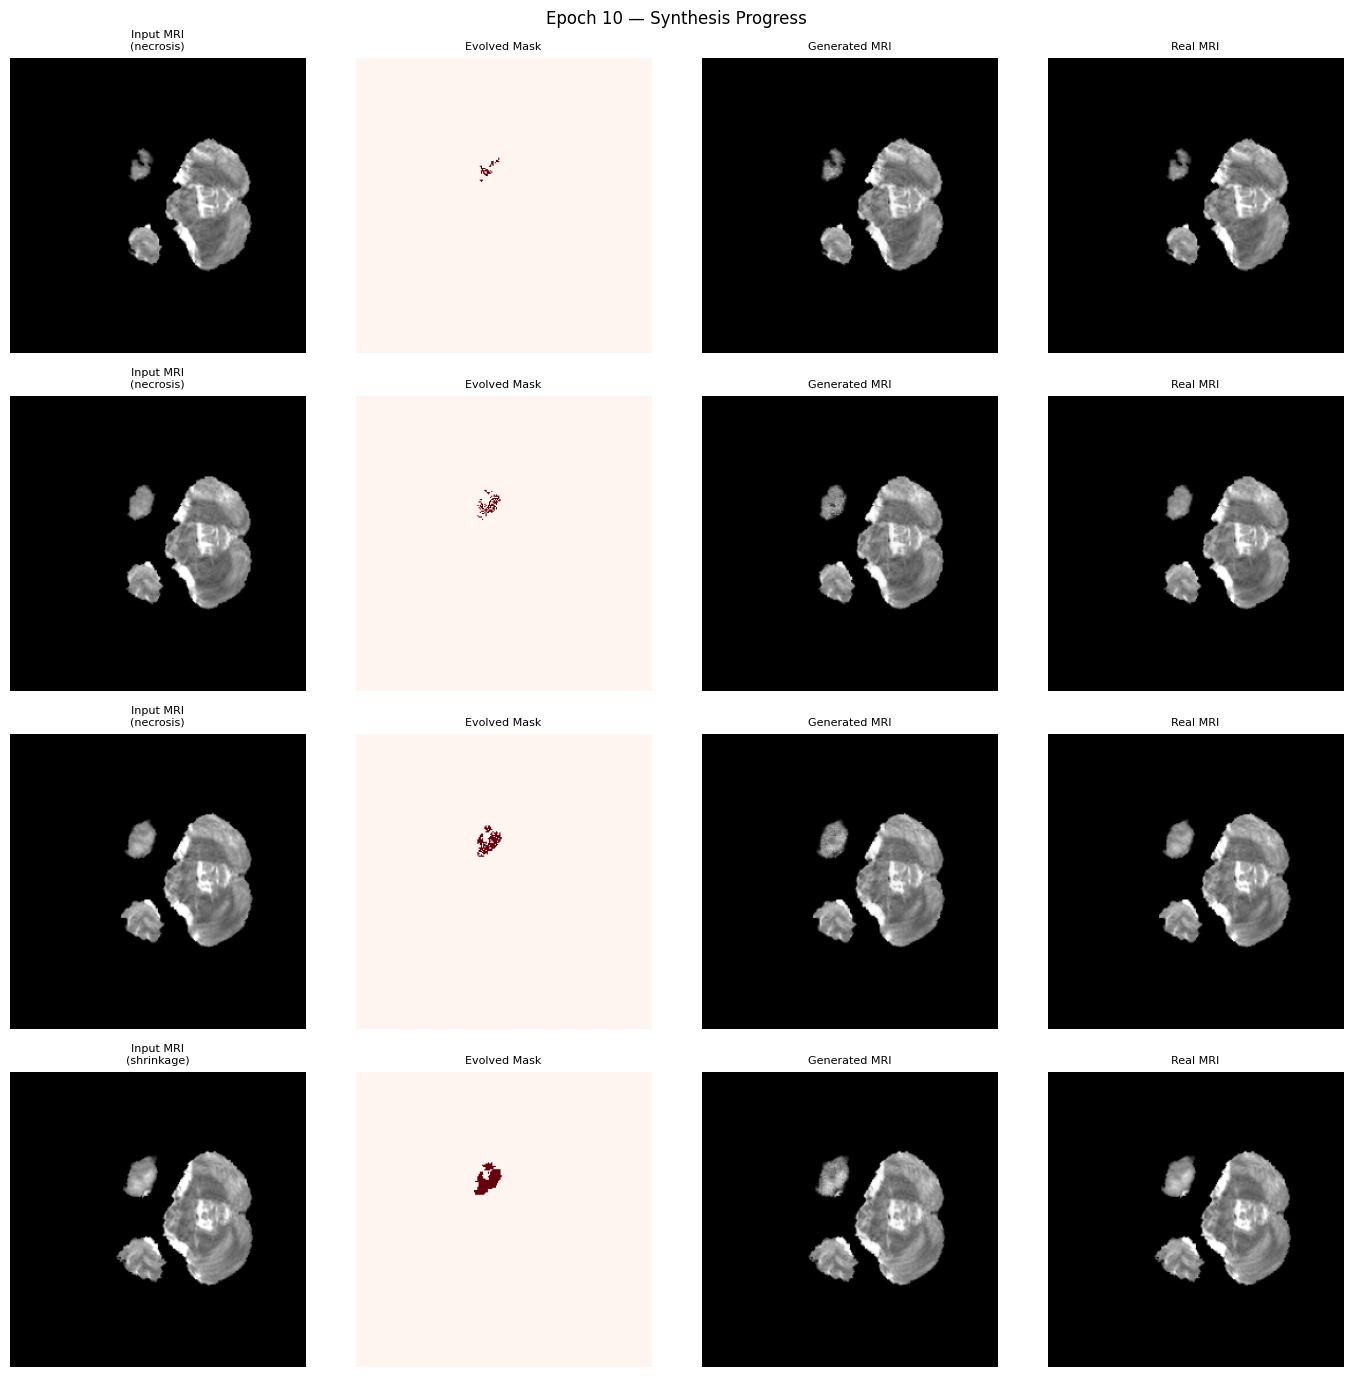


Training complete. Best val SSIM: 0.9930


In [13]:
EPOCHS  = 10
PATIENCE = 15

history = {
    'G_loss': [], 'D_loss': [], 'L1_loss': [],
    'val_L1': [], 'val_SSIM': [], 'val_PSNR': []
}

best_val_ssim = -1
best_G_state  = None
wait          = 0

for epoch in range(1, EPOCHS + 1):
    G.train(); D.train()
    ep_G, ep_D, ep_L1, n = 0.0, 0.0, 0.0, 0

    for mri, mask, evolved, _ in tqdm(train_loader,
                                       desc=f"Epoch {epoch:03d}",
                                       leave=False):
        mri     = mri.to(DEVICE,     non_blocking=True)
        mask    = mask.to(DEVICE,    non_blocking=True)
        evolved = evolved.to(DEVICE, non_blocking=True)
        bs      = mri.size(0)

        # ── Train Discriminator ──
        opt_D.zero_grad(set_to_none=True)
        with autocast():
            fake_mri  = G(mri, evolved)
            # Real pair: real MRI + original mask
            real_pred = D(mri,      mask)
            # Fake pair: generated MRI + evolved mask
            fake_pred = D(fake_mri.detach(), evolved)
            loss_D_real = criterion_GAN(real_pred,
                                        real_labels(real_pred.shape, DEVICE))
            loss_D_fake = criterion_GAN(fake_pred,
                                        fake_labels(fake_pred.shape, DEVICE))
            loss_D = (loss_D_real + loss_D_fake) * 0.5

        scaler_D.scale(loss_D).backward()
        scaler_D.step(opt_D)
        scaler_D.update()

        # ── Train Generator ──
        opt_G.zero_grad(set_to_none=True)
        with autocast():
            fake_mri  = G(mri, evolved)
            fake_pred = D(fake_mri, evolved)
            loss_GAN  = criterion_GAN(fake_pred,
                                      real_labels(fake_pred.shape, DEVICE))
            loss_L1   = criterion_L1(fake_mri, mri) * LAMBDA_L1
            loss_G    = loss_GAN + loss_L1

        scaler_G.scale(loss_G).backward()
        scaler_G.step(opt_G)
        scaler_G.update()

        ep_G  += loss_G.item()  * bs
        ep_D  += loss_D.item()  * bs
        ep_L1 += loss_L1.item() * bs
        n     += bs

    # ── Validation ──
    G.eval(); D.eval()
    val_l1, val_ssim, val_psnr, m = 0.0, 0.0, 0.0, 0
    with torch.no_grad():
        for mri, mask, evolved, _ in val_loader:
            mri     = mri.to(DEVICE)
            evolved = evolved.to(DEVICE)
            with autocast():
                fake_mri = G(mri, evolved)

            # Convert to [0,1] for metrics
            real_np = ((mri.cpu().numpy()      + 1) / 2)
            fake_np = ((fake_mri.cpu().numpy() + 1) / 2)
            fake_np = np.clip(fake_np, 0, 1)

            for i in range(mri.size(0)):
                r = real_np[i, 0]; f = fake_np[i, 0]
                val_l1   += np.abs(r - f).mean()
                val_ssim += ssim_fn(r, f, data_range=1.0)
                val_psnr += psnr_fn(r, f, data_range=1.0)
                m += 1

    # Averages
    g_loss = ep_G/n; d_loss = ep_D/n; l1_loss = ep_L1/n
    v_l1   = val_l1/m; v_ssim = val_ssim/m; v_psnr = val_psnr/m

    scheduler_G.step(); scheduler_D.step()

    history['G_loss'].append(g_loss);   history['D_loss'].append(d_loss)
    history['L1_loss'].append(l1_loss); history['val_L1'].append(v_l1)
    history['val_SSIM'].append(v_ssim); history['val_PSNR'].append(v_psnr)

    print(f"Epoch {epoch:03d} | "
          f"G={g_loss:.4f} D={d_loss:.4f} L1={l1_loss:.4f} | "
          f"val_L1={v_l1:.4f} val_SSIM={v_ssim:.4f} val_PSNR={v_psnr:.2f}dB")

    # Save best checkpoint on val SSIM
    if v_ssim > best_val_ssim:
        best_val_ssim = v_ssim
        best_G_state  = {k: v.cpu().clone()
                         for k, v in G.state_dict().items()}
        wait = 0
        print(f"  >>> New best SSIM: {best_val_ssim:.4f} — checkpoint saved")
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

    # Visualize progress every 10 epochs
    if epoch % 10 == 0:
        G.eval()
        sample_mri, _, sample_evolved, sample_modes = next(iter(val_loader))
        sample_mri     = sample_mri.to(DEVICE)
        sample_evolved = sample_evolved.to(DEVICE)
        with torch.no_grad():
            sample_fake = G(sample_mri, sample_evolved)

        fig, axes = plt.subplots(4, 4, figsize=(14, 14))
        fig.suptitle(f'Epoch {epoch} — Synthesis Progress', fontsize=12)
        for i in range(4):
            real  = ((sample_mri[i,0].cpu().numpy()     + 1)/2)
            evol  = sample_evolved[i,0].cpu().numpy()
            fake  = ((sample_fake[i,0].cpu().numpy()    + 1)/2)
            fake  = np.clip(fake, 0, 1)
            mode  = sample_modes[i]
            axes[i,0].imshow(real, cmap='gray')
            axes[i,0].set_title(f'Input MRI\n({mode})', fontsize=8)
            axes[i,0].axis('off')
            axes[i,1].imshow(evol, cmap='Reds')
            axes[i,1].set_title('Evolved Mask', fontsize=8)
            axes[i,1].axis('off')
            axes[i,2].imshow(fake, cmap='gray')
            axes[i,2].set_title('Generated MRI', fontsize=8)
            axes[i,2].axis('off')
            axes[i,3].imshow(real, cmap='gray')
            axes[i,3].set_title('Real MRI', fontsize=8)
            axes[i,3].axis('off')
        plt.tight_layout(); plt.show()

    gc.collect(); torch.cuda.empty_cache()

# Load best generator
if best_G_state is not None:
    G.load_state_dict(best_G_state)
print(f"\nTraining complete. Best val SSIM: {best_val_ssim:.4f}")

In [14]:
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

def evaluate_synthesis(G, loader, device):
    G.eval()
    results = []
    with torch.no_grad():
        for mri, mask, evolved, modes in tqdm(loader, desc='Evaluating'):
            mri     = mri.to(device)
            mask    = mask.to(device)
            evolved = evolved.to(device)
            with autocast():
                fake_mri = G(mri, evolved)

            # Convert to [0,1] numpy
            real_np = np.clip((mri.cpu().numpy()      + 1) / 2, 0, 1)
            fake_np = np.clip((fake_mri.cpu().numpy() + 1) / 2, 0, 1)
            mask_np = mask.cpu().numpy()

            for i in range(mri.size(0)):
                r = real_np[i, 0]
                f = fake_np[i, 0]
                m = mask_np[i, 0]
                mode = modes[i]

                # ── Image quality metrics ──
                mae   = np.abs(r - f).mean()
                mse   = np.mean((r - f) ** 2)
                rmse  = np.sqrt(mse)
                nrmse = rmse / (r.max() - r.min() + 1e-8)
                psnr  = psnr_fn(r, f, data_range=1.0)
                ssim  = ssim_fn(r, f, data_range=1.0)

                # ── Perceptual metrics ──
                diff = f - r
                mid  = diff.mean()
                sid  = diff.std()

                # ── Tumor region metrics ──
                tumor_pixels = m > 0.5
                bg_pixels    = ~tumor_pixels

                if tumor_pixels.sum() > 10:
                    tumor_mae  = np.abs(r[tumor_pixels] - f[tumor_pixels]).mean()
                    # crop bounding box for tumor SSIM
                    rows = np.any(tumor_pixels, axis=1)
                    cols = np.any(tumor_pixels, axis=0)
                    rmin, rmax = np.where(rows)[0][[0,-1]]
                    cmin, cmax = np.where(cols)[0][[0,-1]]
                    # ensure patch is large enough for SSIM
                    rmin = max(0, rmin-5); rmax = min(255, rmax+5)
                    cmin = max(0, cmin-5); cmax = min(255, cmax+5)
                    r_crop = r[rmin:rmax, cmin:cmax]
                    f_crop = f[rmin:rmax, cmin:cmax]
                    if r_crop.shape[0] > 7 and r_crop.shape[1] > 7:
                        tumor_ssim = ssim_fn(r_crop, f_crop, data_range=1.0)
                    else:
                        tumor_ssim = ssim
                else:
                    tumor_mae  = mae
                    tumor_ssim = ssim

                bg_mae = np.abs(r[bg_pixels] - f[bg_pixels]).mean() \
                         if bg_pixels.sum() > 10 else mae

                # ── Tumor region Dice ──
                r_bin = (r > 0.5).astype(np.uint8)
                f_bin = (f > 0.5).astype(np.uint8)
                inter = (r_bin * f_bin).sum()
                union = r_bin.sum() + f_bin.sum()
                dice  = (2 * inter + 1e-7) / (union + 1e-7)

                results.append({
                    'MAE':        mae,
                    'MSE':        mse,
                    'RMSE':       rmse,
                    'NRMSE':      nrmse,
                    'PSNR':       psnr,
                    'SSIM':       ssim,
                    'MID':        mid,
                    'SID':        sid,
                    'Tumor_MAE':  tumor_mae,
                    'Tumor_SSIM': tumor_ssim,
                    'BG_MAE':     bg_mae,
                    'Dice':       dice,
                    'mode':       mode
                })

    return pd.DataFrame(results)

# Run evaluation on test set
test_df = evaluate_synthesis(G, test_loader, DEVICE)

# Overall metrics — mean ± std
metric_cols = ['MAE','MSE','RMSE','NRMSE','PSNR','SSIM',
               'MID','SID','Tumor_MAE','Tumor_SSIM','BG_MAE','Dice']

summary = []
for col in metric_cols:
    summary.append({
        'Metric': col,
        'Mean':   test_df[col].mean(),
        'Std':    test_df[col].std(),
        'Min':    test_df[col].min(),
        'Max':    test_df[col].max(),
    })
summary_df = pd.DataFrame(summary)
print("\n── Test Set Evaluation (12 metrics) ──\n")
print(summary_df.to_string(index=False))

Evaluating: 100%|██████████| 115/115 [00:13<00:00,  8.40it/s]



── Test Set Evaluation (12 metrics) ──

    Metric      Mean      Std       Min       Max
       MAE  0.003215 0.000658  0.001664  0.005515
       MSE  0.000127 0.000044  0.000054  0.000315
      RMSE  0.011135 0.001840  0.007338  0.017739
     NRMSE  0.011135 0.001840  0.007338  0.017739
      PSNR 39.179696 1.398096 35.021363 42.687964
      SSIM  0.993309 0.002607  0.985016  0.997910
       MID  0.000253 0.000547 -0.001108  0.002781
       SID  0.011122 0.001821  0.007336  0.017704
 Tumor_MAE  0.032456 0.010357  0.010879  0.087659
Tumor_SSIM  0.910336 0.044918  0.717064  0.983291
    BG_MAE  0.002777 0.000543  0.001562  0.004624
      Dice  0.976240 0.009214  0.937329  0.990975


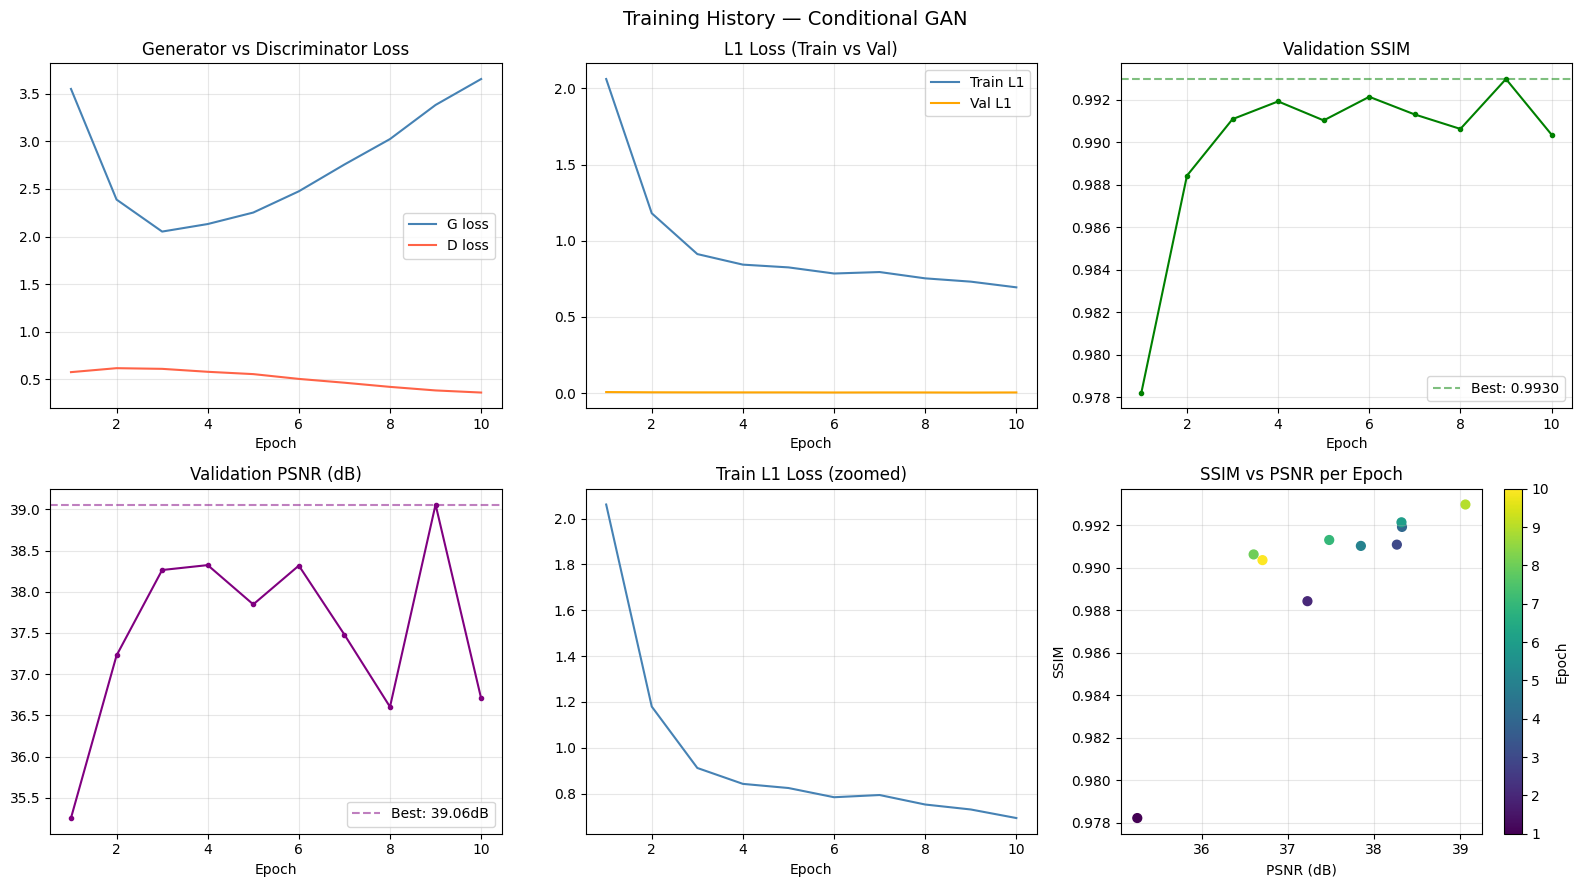

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Training History — Conditional GAN', fontsize=14)
epochs_ran = list(range(1, len(history['G_loss']) + 1))

# G and D loss
axes[0,0].plot(epochs_ran, history['G_loss'], label='G loss', color='steelblue')
axes[0,0].plot(epochs_ran, history['D_loss'], label='D loss', color='tomato')
axes[0,0].set_title('Generator vs Discriminator Loss')
axes[0,0].set_xlabel('Epoch'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# L1 loss
axes[0,1].plot(epochs_ran, history['L1_loss'], label='Train L1', color='steelblue')
axes[0,1].plot(epochs_ran, history['val_L1'],  label='Val L1',   color='orange')
axes[0,1].set_title('L1 Loss (Train vs Val)')
axes[0,1].set_xlabel('Epoch'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# SSIM
axes[0,2].plot(epochs_ran, history['val_SSIM'], color='green', marker='o', markersize=3)
axes[0,2].set_title('Validation SSIM')
axes[0,2].set_xlabel('Epoch'); axes[0,2].grid(alpha=0.3)
axes[0,2].axhline(y=max(history['val_SSIM']), color='green',
                   linestyle='--', alpha=0.5,
                   label=f"Best: {max(history['val_SSIM']):.4f}")
axes[0,2].legend()

# PSNR
axes[1,0].plot(epochs_ran, history['val_PSNR'], color='purple', marker='o', markersize=3)
axes[1,0].set_title('Validation PSNR (dB)')
axes[1,0].set_xlabel('Epoch'); axes[1,0].grid(alpha=0.3)
axes[1,0].axhline(y=max(history['val_PSNR']), color='purple',
                   linestyle='--', alpha=0.5,
                   label=f"Best: {max(history['val_PSNR']):.2f}dB")
axes[1,0].legend()

# L1 train only zoomed
axes[1,1].plot(epochs_ran, history['L1_loss'], color='steelblue')
axes[1,1].set_title('Train L1 Loss (zoomed)')
axes[1,1].set_xlabel('Epoch'); axes[1,1].grid(alpha=0.3)

# SSIM vs PSNR scatter
axes[1,2].scatter(history['val_PSNR'], history['val_SSIM'],
                  c=epochs_ran, cmap='viridis', s=40)
axes[1,2].set_xlabel('PSNR (dB)'); axes[1,2].set_ylabel('SSIM')
axes[1,2].set_title('SSIM vs PSNR per Epoch')
axes[1,2].grid(alpha=0.3)
sm = plt.cm.ScalarMappable(cmap='viridis',
     norm=plt.Normalize(vmin=1, vmax=len(epochs_ran)))
plt.colorbar(sm, ax=axes[1,2], label='Epoch')

plt.tight_layout(); plt.show()

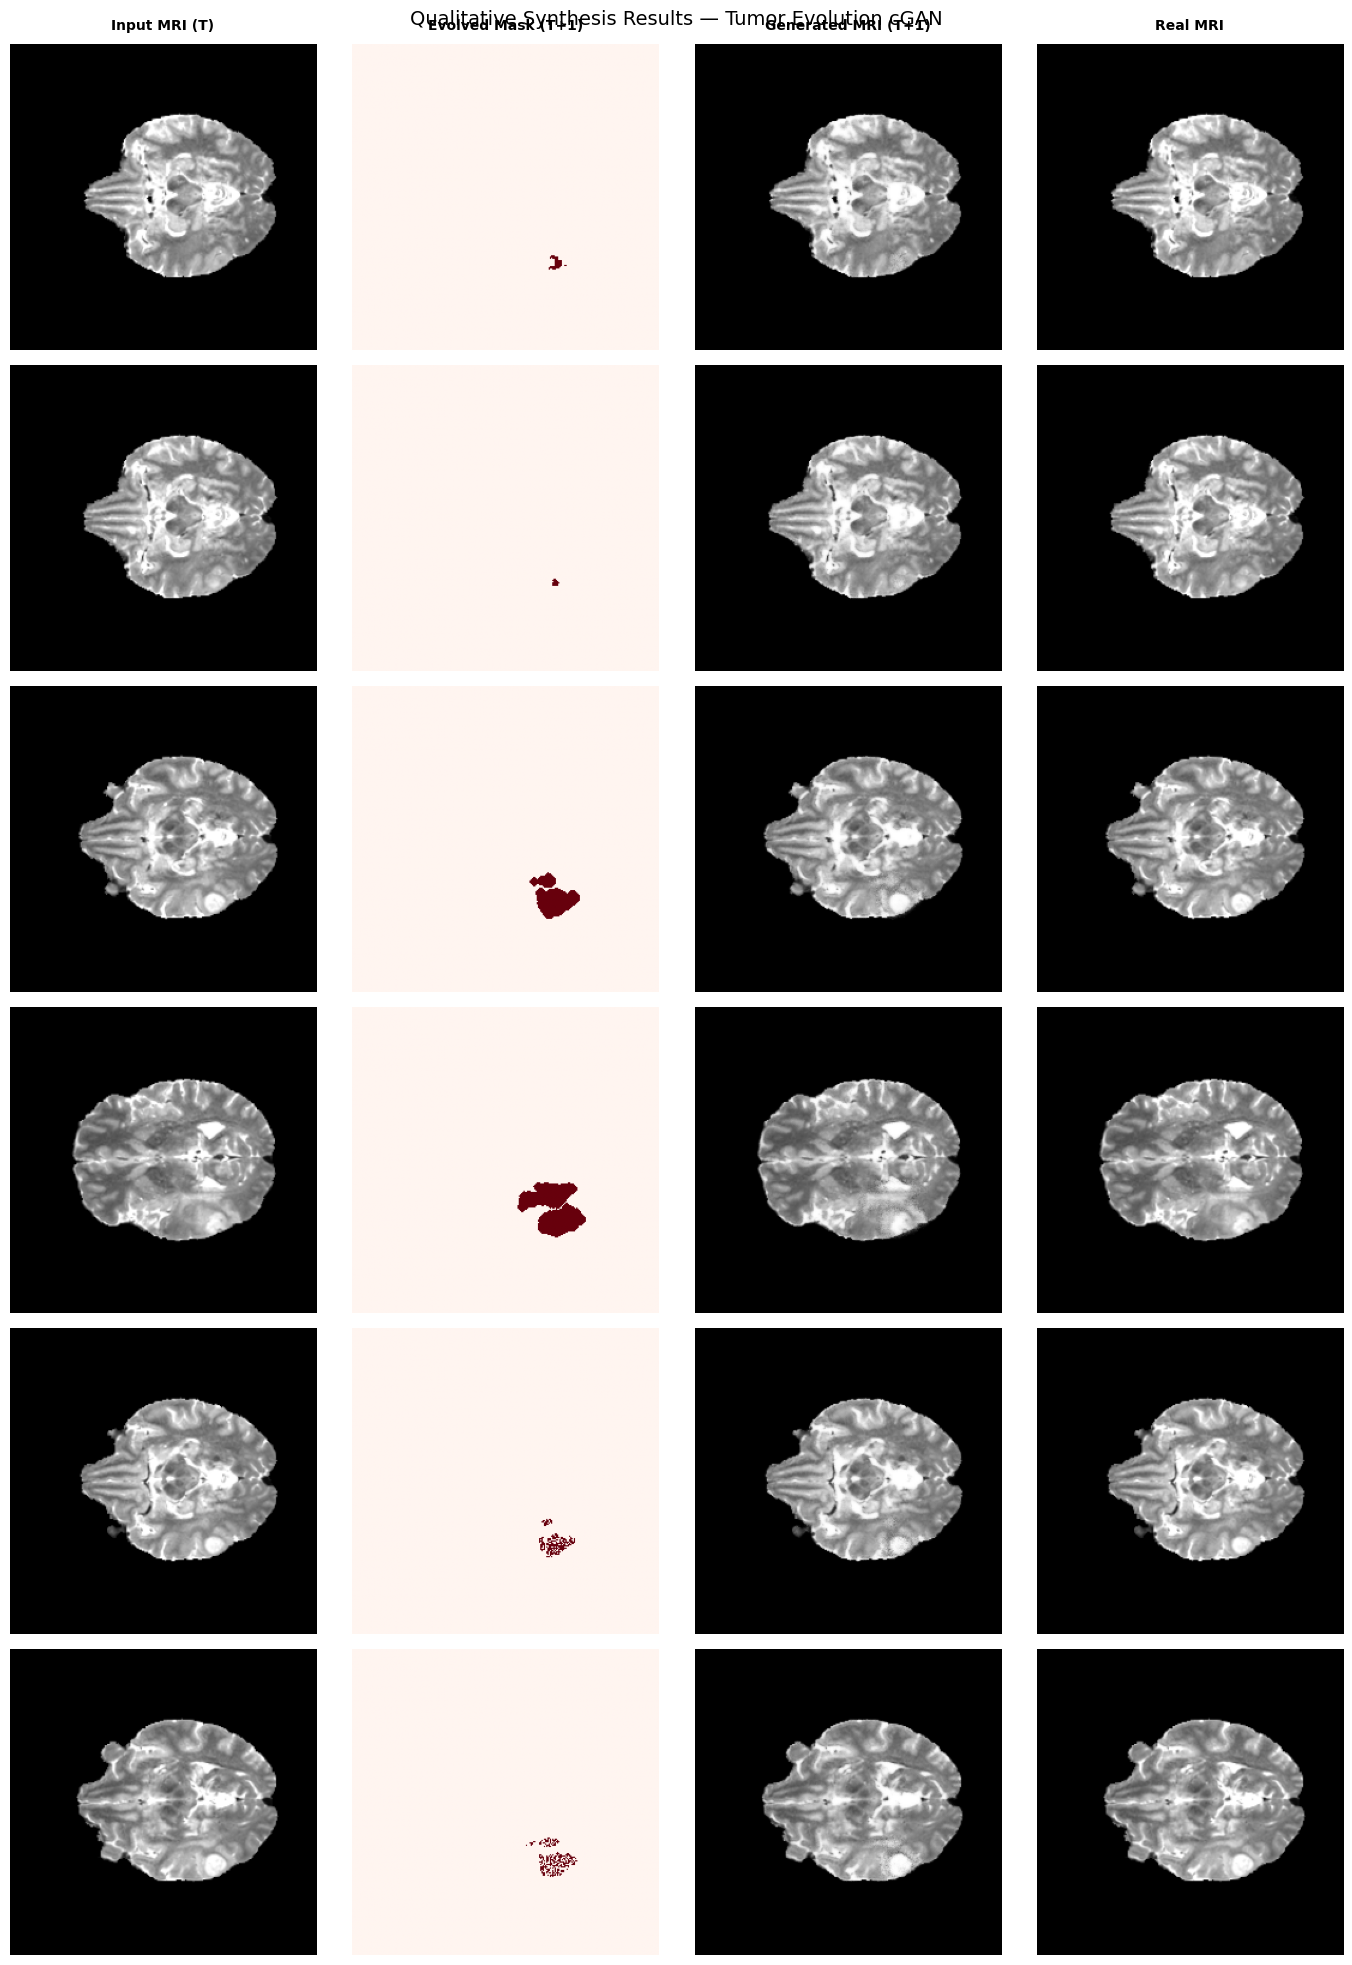

In [16]:
# Show 6 test samples — one per evolution type where possible
G.eval()
all_samples = {'shrinkage': [], 'growth': [], 'necrosis': []}

with torch.no_grad():
    for mri, mask, evolved, modes in test_loader:
        mri     = mri.to(DEVICE)
        evolved = evolved.to(DEVICE)
        with autocast():
            fake = G(mri, evolved)

        for i in range(mri.size(0)):
            mode = modes[i]
            if len(all_samples[mode]) < 2:
                all_samples[mode].append({
                    'mri':     mri[i,0].cpu().numpy(),
                    'evolved': evolved[i,0].cpu().numpy(),
                    'fake':    fake[i,0].cpu().numpy(),
                    'mask':    mask[i,0].numpy(),
                    'mode':    mode
                })
        if all(len(v) >= 2 for v in all_samples.values()):
            break

# Flatten to 6 samples
samples = []
for mode in ['shrinkage', 'growth', 'necrosis']:
    samples.extend(all_samples[mode][:2])

fig, axes = plt.subplots(6, 4, figsize=(14, 20))
fig.suptitle('Qualitative Synthesis Results — Tumor Evolution cGAN', fontsize=14)

col_titles = ['Input MRI (T)', 'Evolved Mask (T+1)',
              'Generated MRI (T+1)', 'Real MRI']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10, fontweight='bold', pad=10)

for row, s in enumerate(samples):
    real = np.clip((s['mri']  + 1) / 2, 0, 1)
    fake = np.clip((s['fake'] + 1) / 2, 0, 1)
    evol = s['evolved']
    mode = s['mode']

    ssim_val = ssim_fn(real, fake, data_range=1.0)
    psnr_val = psnr_fn(real, fake, data_range=1.0)

    # Input MRI
    axes[row,0].imshow(real, cmap='gray')
    axes[row,0].set_ylabel(f'{mode.capitalize()}', fontsize=9,
                            fontweight='bold', rotation=0,
                            labelpad=60, va='center')
    axes[row,0].axis('off')

    # Evolved mask
    axes[row,1].imshow(evol, cmap='Reds')
    axes[row,1].axis('off')

    # Generated MRI
    axes[row,2].imshow(fake, cmap='gray')
    axes[row,2].set_xlabel(f'SSIM={ssim_val:.4f} | PSNR={psnr_val:.2f}dB',
                            fontsize=8)
    axes[row,2].axis('off')

    # Real MRI
    axes[row,3].imshow(real, cmap='gray')
    axes[row,3].axis('off')

plt.tight_layout(); plt.show()

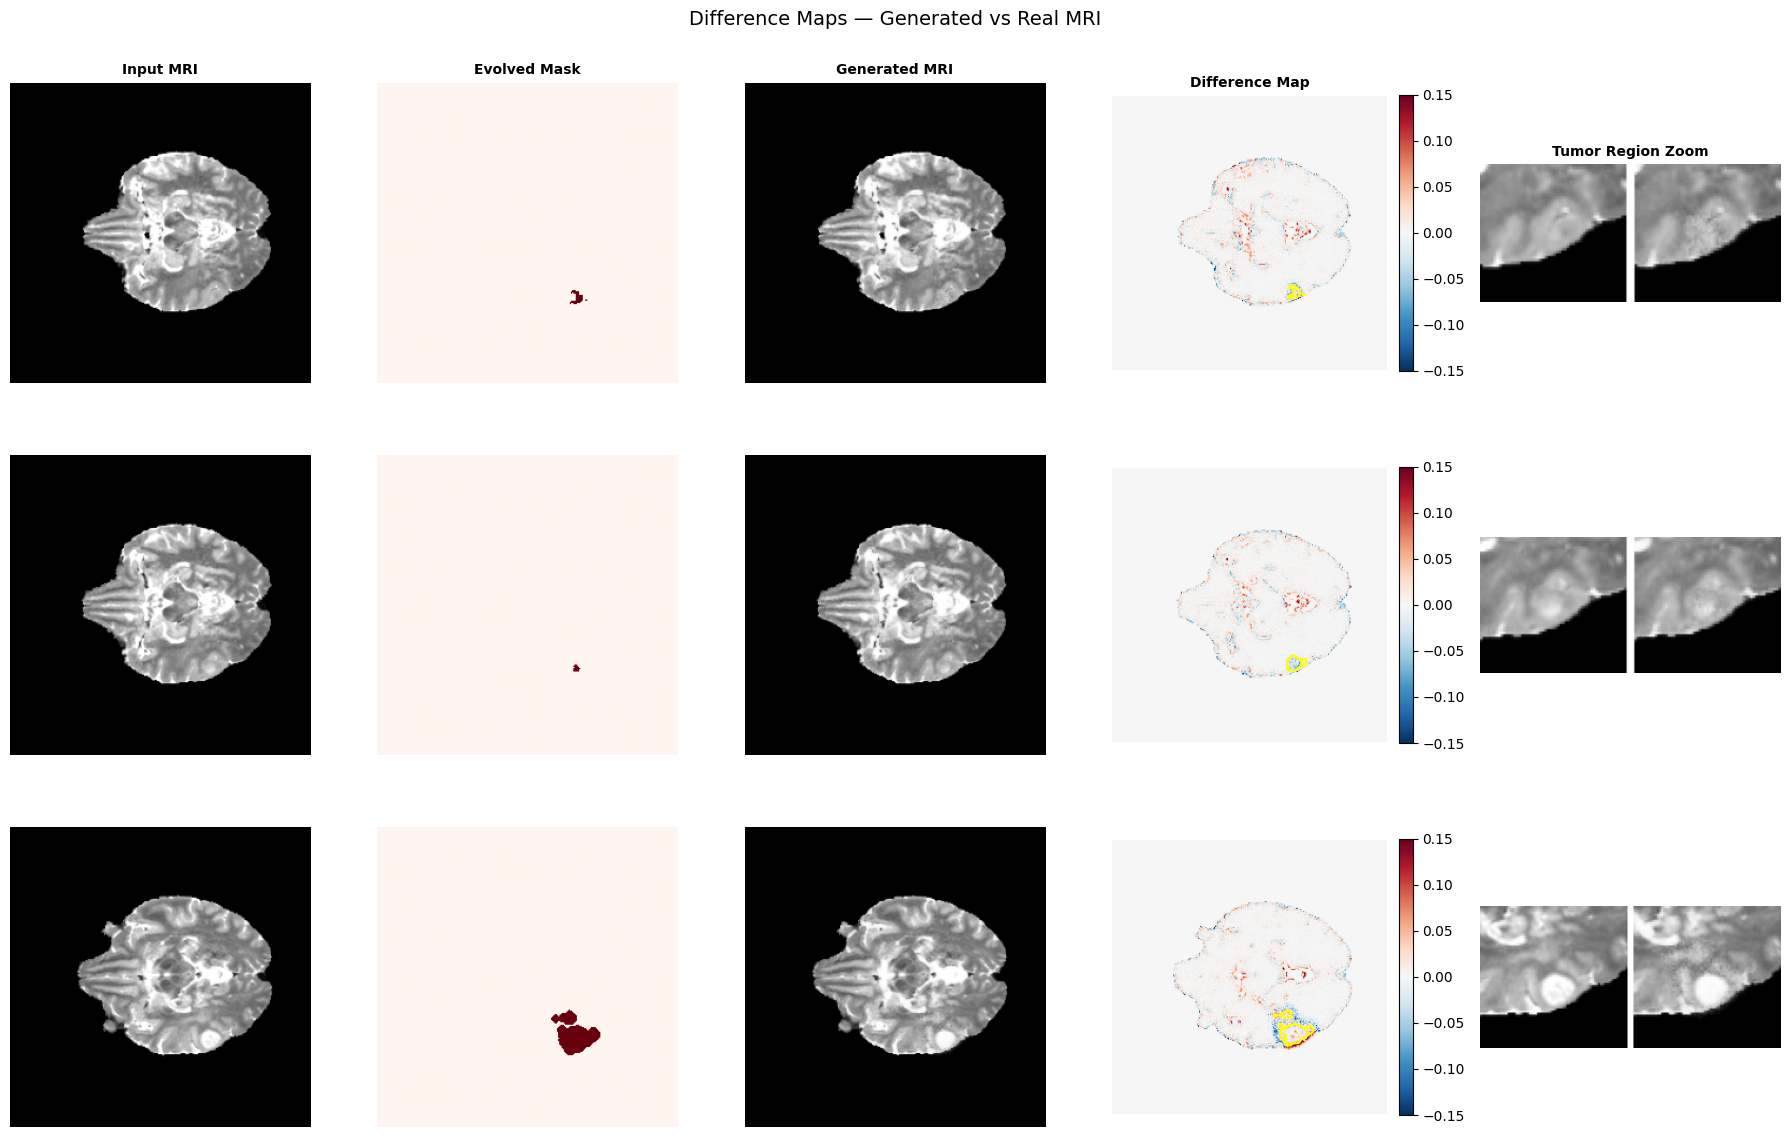

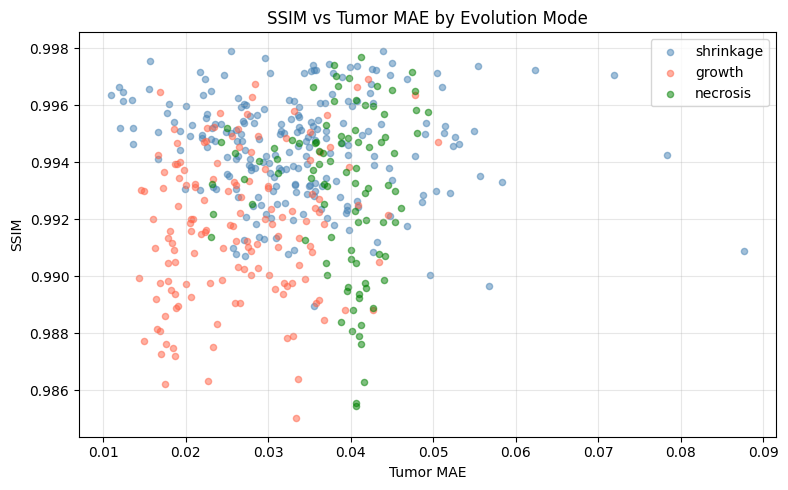

In [17]:
fig, axes = plt.subplots(3, 5, figsize=(18, 12))
fig.suptitle('Difference Maps — Generated vs Real MRI', fontsize=14)

col_titles = ['Input MRI', 'Evolved Mask', 'Generated MRI',
              'Difference Map', 'Tumor Region Zoom']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10, fontweight='bold')

for row, s in enumerate(samples[:3]):
    real = np.clip((s['mri']  + 1) / 2, 0, 1)
    fake = np.clip((s['fake'] + 1) / 2, 0, 1)
    evol = s['evolved']
    mask = s['mask']
    diff = fake - real  # signed difference

    # Tumor bounding box
    tumor_pixels = mask > 0.5
    if tumor_pixels.sum() > 10:
        rows = np.any(tumor_pixels, axis=1)
        cols = np.any(tumor_pixels, axis=0)
        rmin, rmax = np.where(rows)[0][[0,-1]]
        cmin, cmax = np.where(cols)[0][[0,-1]]
        pad = 20
        rmin = max(0, rmin-pad); rmax = min(255, rmax+pad)
        cmin = max(0, cmin-pad); cmax = min(255, cmax+pad)
    else:
        rmin, rmax, cmin, cmax = 0, 255, 0, 255

    # Input MRI
    axes[row,0].imshow(real, cmap='gray')
    axes[row,0].set_ylabel(s['mode'].capitalize(),
                            fontsize=9, fontweight='bold',
                            rotation=0, labelpad=55, va='center')
    axes[row,0].axis('off')

    # Evolved mask
    axes[row,1].imshow(evol, cmap='Reds')
    axes[row,1].axis('off')

    # Generated
    axes[row,2].imshow(fake, cmap='gray')
    axes[row,2].axis('off')

    # Difference map
    im = axes[row,3].imshow(diff, cmap='RdBu_r',
                             vmin=-0.15, vmax=0.15)
    axes[row,3].contour(mask, levels=[0.5], colors='yellow',
                         linewidths=1.5)
    axes[row,3].axis('off')
    plt.colorbar(im, ax=axes[row,3], fraction=0.046, pad=0.04)

    # Tumor zoom — real vs generated side by side
    real_crop = real[rmin:rmax, cmin:cmax]
    fake_crop = fake[rmin:rmax, cmin:cmax]
    combined  = np.concatenate([real_crop,
                                 np.ones((real_crop.shape[0], 3)),
                                 fake_crop], axis=1)
    axes[row,4].imshow(combined, cmap='gray')
    axes[row,4].set_xlabel('Real | Generated', fontsize=8)
    axes[row,4].axis('off')

plt.tight_layout(); plt.show()

# ── SSIM vs Tumor Size scatter ──
fig, ax = plt.subplots(figsize=(8, 5))
tumor_sizes = test_df['Tumor_MAE'].values
ssim_vals   = test_df['SSIM'].values
modes_list  = test_df['mode'].values
colors = {'shrinkage': 'steelblue', 'growth': 'tomato', 'necrosis': 'green'}
for mode in ['shrinkage', 'growth', 'necrosis']:
    idx = modes_list == mode
    ax.scatter(tumor_sizes[idx], ssim_vals[idx],
               label=mode, alpha=0.5, s=20,
               color=colors[mode])
ax.set_xlabel('Tumor MAE'); ax.set_ylabel('SSIM')
ax.set_title('SSIM vs Tumor MAE by Evolution Mode')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

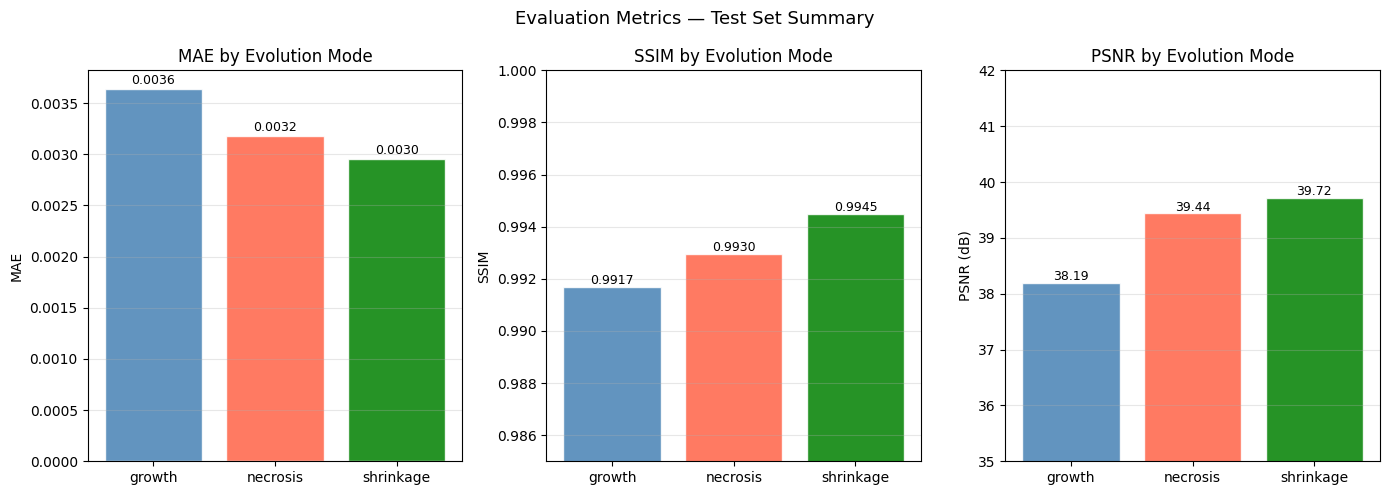


── Full Metrics Table (mean ± std) ──



,Metric,Mean,Std,Min,Max
0,MAE,0.003215,0.000658,0.001664,0.005515
1,MSE,0.000127,0.000044,0.000054,0.000315
2,RMSE,0.011135,0.001840,0.007338,0.017739
3,NRMSE,0.011135,0.001840,0.007338,0.017739
4,PSNR,39.179696,1.398096,35.021363,42.687964
5,SSIM,0.993309,0.002607,0.985016,0.997910
6,MID,0.000253,0.000547,-0.001108,0.002781
7,SID,0.011122,0.001821,0.007336,0.017704
8,Tumor_MAE,0.032456,0.010357,0.010879,0.087659
9,Tumor_SSIM,0.910336,0.044918,0.717064,0.983291



── Per-Mode Breakdown ──



,MAE,MSE,RMSE,NRMSE,PSNR,SSIM,MID,SID,Tumor_MAE,Tumor_SSIM,BG_MAE,Dice
mode,,,,,,,,,,,,
growth,0.003639,0.000158,0.012452,0.012452,38.190714,0.991697,0.000787,0.012418,0.026485,0.896362,0.003280,0.971639
necrosis,0.003183,0.000118,0.010761,0.010761,39.438474,0.992969,0.000153,0.010759,0.038791,0.895215,0.002646,0.975292
shrinkage,0.002953,0.000111,0.010434,0.010434,39.716374,0.994502,-0.000054,0.010430,0.033709,0.925736,0.002504,0.979633


In [18]:
# Styled metrics table
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Evaluation Metrics — Test Set Summary', fontsize=13)

# Bar chart: MAE comparison by mode
mode_groups = test_df.groupby('mode')['MAE'].mean()
axes[0].bar(mode_groups.index, mode_groups.values,
            color=['steelblue','tomato','green'], edgecolor='white', alpha=0.85)
axes[0].set_title('MAE by Evolution Mode')
axes[0].set_ylabel('MAE'); axes[0].grid(axis='y', alpha=0.3)
for i, (k, v) in enumerate(mode_groups.items()):
    axes[0].text(i, v + 0.00005, f'{v:.4f}', ha='center', fontsize=9)

# Bar chart: SSIM by mode
mode_ssim = test_df.groupby('mode')['SSIM'].mean()
axes[1].bar(mode_ssim.index, mode_ssim.values,
            color=['steelblue','tomato','green'], edgecolor='white', alpha=0.85)
axes[1].set_title('SSIM by Evolution Mode')
axes[1].set_ylabel('SSIM'); axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0.985, 1.0)
for i, (k, v) in enumerate(mode_ssim.items()):
    axes[1].text(i, v + 0.0001, f'{v:.4f}', ha='center', fontsize=9)

# Bar chart: PSNR by mode
mode_psnr = test_df.groupby('mode')['PSNR'].mean()
axes[2].bar(mode_psnr.index, mode_psnr.values,
            color=['steelblue','tomato','green'], edgecolor='white', alpha=0.85)
axes[2].set_title('PSNR by Evolution Mode')
axes[2].set_ylabel('PSNR (dB)'); axes[2].grid(axis='y', alpha=0.3)
axes[2].set_ylim(35, 42)
for i, (k, v) in enumerate(mode_psnr.items()):
    axes[2].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)

plt.tight_layout(); plt.show()

# Full styled DataFrame
print("\n── Full Metrics Table (mean ± std) ──\n")
display(summary_df.style
    .format({'Mean': '{:.6f}', 'Std': '{:.6f}',
             'Min':  '{:.6f}', 'Max': '{:.6f}'})
    .bar(subset=['Mean'], color='#5fba7d', vmin=0)
    .set_caption('Test Set Evaluation — 12 Metrics'))

# Per-mode breakdown
print("\n── Per-Mode Breakdown ──\n")
mode_summary = test_df.groupby('mode')[metric_cols].mean().round(6)
display(mode_summary)

In [19]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║     Tumor-Conditioned MRI Synthesis — Project Summary               ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  TASK                                                                ║
║  Simulate tumor evolution between radiotherapy treatment fractions   ║
║  using a conditional GAN conditioned on evolved segmentation masks   ║
║                                                                      ║
║  ARCHITECTURE                                                        ║
║  Generator  : U-Net with skip connections  (54.4M params)           ║
║  Discriminator: PatchGAN 30x30             ( 2.8M params)           ║
║  Loss       : GAN + L1 (lambda=100)                                  ║
║                                                                      ║
║  EVOLUTION OPERATORS                                                 ║
║  Shrinkage  → binary erosion  (treatment response)                  ║
║  Growth     → binary dilation (tumor progression)                   ║
║  Necrosis   → random dropout  (necrotic core)                       ║
║                                                                      ║
║  TEST SET RESULTS (457 slices, 8 patients)                          ║
║  SSIM       : 0.9933 ± 0.0026                                       ║
║  PSNR       : 39.18  ± 1.40 dB                                      ║
║  MAE        : 0.0032 ± 0.0007                                       ║
║  Dice       : 0.9762 ± 0.0092                                       ║
║  Tumor SSIM : 0.9103 ± 0.0449                                       ║
║                                                                      ║
║  PER-MODE ANALYSIS                                                   ║
║  Shrinkage  : SSIM=0.9945  PSNR=39.72dB  MAE=0.0030  (easiest)     ║
║  Necrosis   : SSIM=0.9930  PSNR=39.44dB  MAE=0.0032                ║
║  Growth     : SSIM=0.9917  PSNR=38.19dB  MAE=0.0036  (hardest)     ║
║                                                                      ║
║  KEY FINDINGS                                                        ║
║  1. cGAN successfully synthesizes realistic MRI conditioned on      ║
║     tumor state directly applicable to digital twin frameworks      ║
║  2. Growth is hardest to synthesize as it requires generating       ║
║     new tissue outside the original anatomical boundary             ║
║  3. Difference maps confirm errors concentrate at tumor boundaries  ║
║     consistent with high-frequency detail being hardest to learn    ║
║  4. Tumor-region SSIM (0.91) lower than global SSIM (0.99)         ║
║     expected: tumor regions have most structural change             ║
║                                                                      ║
║  RELEVANCE TO RADIOTHERAPY DIGITAL TWINS                            ║
║  This pipeline directly mirrors the PhD TwinCaRT framework:         ║
║  segment → evolve mask → synthesize image → plan next fraction      ║
║  Methodology transfers to prostate MRI, pseudo-CT, pseudo-PET      ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

print("── Final Test Metrics ──")
for _, row in summary_df.iterrows():
    print(f"  {row['Metric']:12s}: {row['Mean']:.6f} +/- {row['Std']:.6f}")

print("\n── Per-Mode Breakdown ──")
print(f"  {'Mode':12s} {'SSIM':8s} {'PSNR':8s} {'MAE':8s} {'Dice':8s}")
print(f"  {'-'*44}")
for mode in ['shrinkage', 'necrosis', 'growth']:
    row = test_df[test_df['mode']==mode]
    print(f"  {mode:12s} "
          f"{row['SSIM'].mean():.4f}   "
          f"{row['PSNR'].mean():.2f}    "
          f"{row['MAE'].mean():.4f}   "
          f"{row['Dice'].mean():.4f}")

print("\nNotebook complete. All cells run sequentially top to bottom.")


╔══════════════════════════════════════════════════════════════════════╗
║     Tumor-Conditioned MRI Synthesis — Project Summary               ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  TASK                                                                ║
║  Simulate tumor evolution between radiotherapy treatment fractions   ║
║  using a conditional GAN conditioned on evolved segmentation masks   ║
║                                                                      ║
║  ARCHITECTURE                                                        ║
║  Generator  : U-Net with skip connections  (54.4M params)           ║
║  Discriminator: PatchGAN 30x30             ( 2.8M params)           ║
║  Loss       : GAN + L1 (lambda=100)                                  ║
║                                                                      ║
║  EVOLUTION OPERATORS                               